# Lab 1b: Data Preparation & Dimensionality Reduction

**Signal, Image and Video Processing**

In this lab, we'll practice:
1. Handling missing values
2. Normalization and standardization
3. Log transformation and outlier handling
4. PCA for dimensionality reduction
5. Comparing PCA, LDA, t-SNE, and UMAP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_digits, fetch_california_housing, fetch_openml
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats
from scipy.stats.mstats import winsorize
import warnings
warnings.filterwarnings('ignore')

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("UMAP not installed. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries loaded!")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Libraries loaded!


---
## Part 1: Handling Missing Values (Titanic Dataset)

In [14]:
# Load Titanic dataset
titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
df = titanic.data.copy()
df['survived'] = titanic.target
print(f"Loaded: {df.shape[0]} passengers, {df.shape[1]} columns")
df.head()

Loaded: 1309 passengers, 14 columns


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


In [15]:
# Analyze missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Count'] > 0].sort_values('Percent', ascending=False))

Missing Values:
           Count  Percent
body        1188     90.8
cabin       1014     77.5
boat         823     62.9
home.dest    564     43.1
age          263     20.1
embarked       2      0.2
fare           1      0.1


In [16]:
# Strategy 1: Drop columns with >50% missing
threshold = 50
cols_to_drop = missing_df[missing_df['Percent'] > threshold].index.tolist()
print(f"Dropping columns with >{threshold}% missing: {cols_to_drop}")
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

Dropping columns with >50% missing: ['cabin', 'boat', 'body']


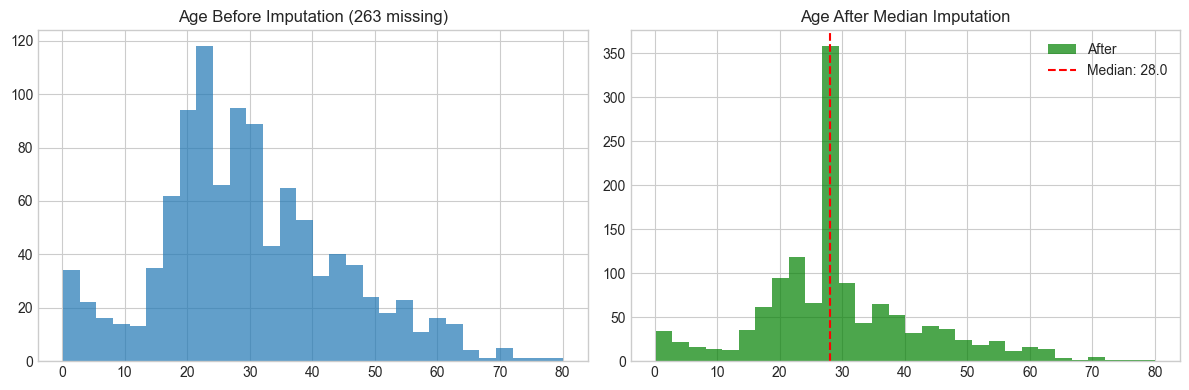

In [17]:
# Strategy 2: Impute numerical with median
if 'age' in df_clean.columns and df_clean['age'].isnull().sum() > 0:
    median_age = df_clean['age'].median()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df_clean['age'].hist(ax=axes[0], bins=30, alpha=0.7, label='Before')
    axes[0].set_title(f'Age Before Imputation ({df_clean["age"].isnull().sum()} missing)')
    
    df_clean['age'].fillna(median_age, inplace=True)
    
    df_clean['age'].hist(ax=axes[1], bins=30, alpha=0.7, color='green', label='After')
    axes[1].axvline(median_age, color='red', linestyle='--', label=f'Median: {median_age:.1f}')
    axes[1].set_title('Age After Median Imputation')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [18]:
# Strategy 3: Impute categorical with mode
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Imputed {col} with mode: {mode_val}")

Imputed embarked with mode: S
Imputed home.dest with mode: New York, NY


---
## Part 2: Normalization and Standardization (Wine Dataset)

In [19]:
# Load Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = wine.feature_names

print(f"Wine: {X_wine.shape[0]} samples, {X_wine.shape[1]} features")
print("\nFeature ranges (note the scale differences!):")
for i, name in enumerate(feature_names):
    print(f"  {name}: [{X_wine[:,i].min():.2f}, {X_wine[:,i].max():.2f}]")

Wine: 178 samples, 13 features

Feature ranges (note the scale differences!):
  alcohol: [11.03, 14.83]
  malic_acid: [0.74, 5.80]
  ash: [1.36, 3.23]
  alcalinity_of_ash: [10.60, 30.00]
  magnesium: [70.00, 162.00]
  total_phenols: [0.98, 3.88]
  flavanoids: [0.34, 5.08]
  nonflavanoid_phenols: [0.13, 0.66]
  proanthocyanins: [0.41, 3.58]
  color_intensity: [1.28, 13.00]
  hue: [0.48, 1.71]
  od280/od315_of_diluted_wines: [1.27, 4.00]
  proline: [278.00, 1680.00]


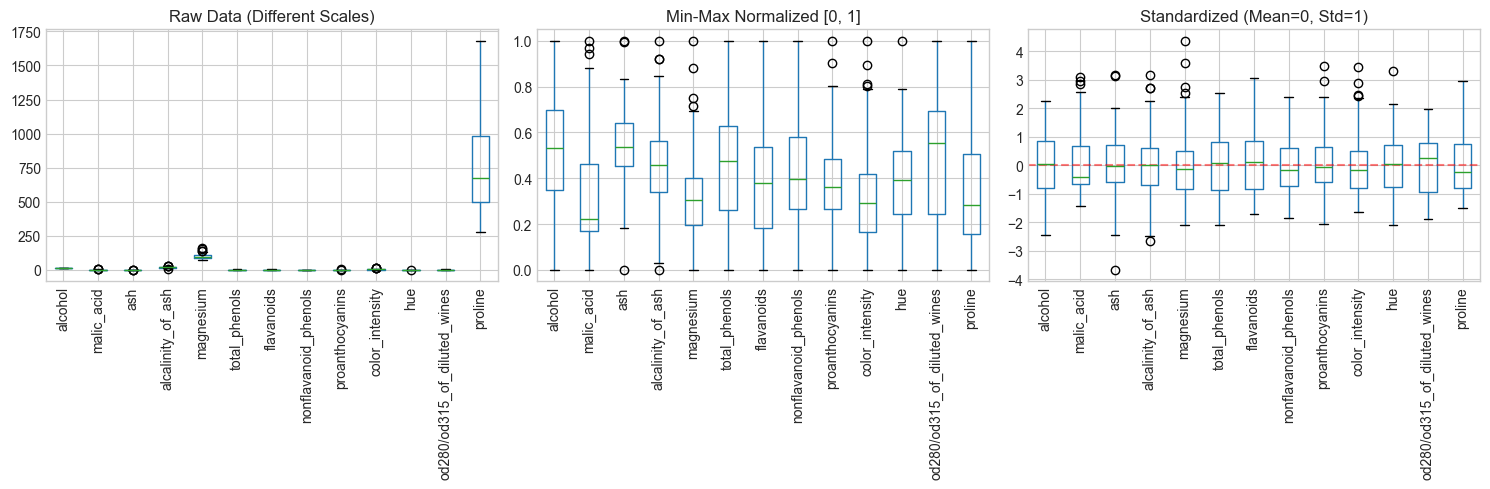

In [20]:
# Compare Raw vs Min-Max vs Standard scaling
X_minmax = MinMaxScaler().fit_transform(X_wine)
X_standard = StandardScaler().fit_transform(X_wine)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Raw
pd.DataFrame(X_wine, columns=feature_names).boxplot(ax=axes[0], rot=90)
axes[0].set_title('Raw Data (Different Scales)')

# Min-Max
pd.DataFrame(X_minmax, columns=feature_names).boxplot(ax=axes[1], rot=90)
axes[1].set_title('Min-Max Normalized [0, 1]')

# Standardized
pd.DataFrame(X_standard, columns=feature_names).boxplot(ax=axes[2], rot=90)
axes[2].set_title('Standardized (Mean=0, Std=1)')
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Part 3: Log Transformation and Outliers (California Housing)

In [21]:
# Load California Housing
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# Show skewness
print("Skewness (>1 or <-1 = highly skewed):")
print(df_housing.skew().sort_values(ascending=False).round(2))

Skewness (>1 or <-1 = highly skewed):
AveOccup      97.64
AveBedrms     31.32
AveRooms      20.70
Population     4.94
MedInc         1.65
Latitude       0.47
HouseAge       0.06
Longitude     -0.30
dtype: float64


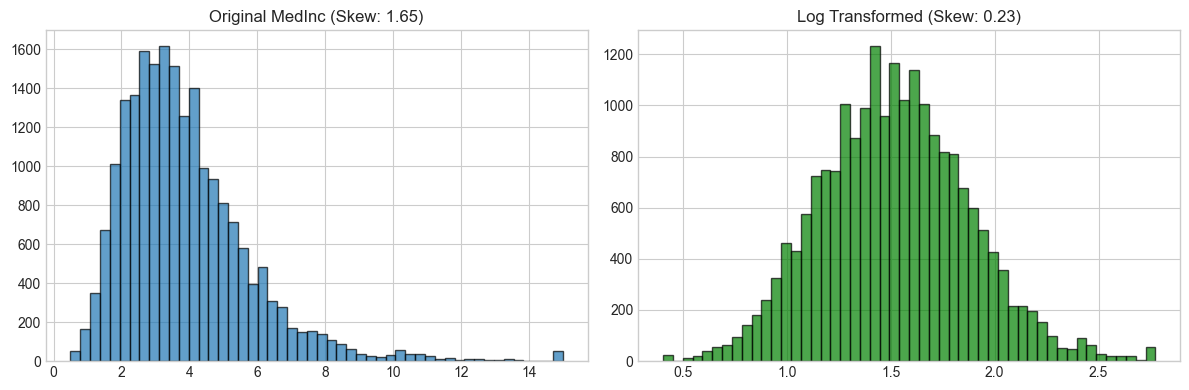

In [22]:
# Log transformation for skewed feature
feature = 'MedInc'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_housing[feature], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Original {feature} (Skew: {df_housing[feature].skew():.2f})')

log_feature = np.log1p(df_housing[feature])
axes[1].hist(log_feature, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title(f'Log Transformed (Skew: {log_feature.skew():.2f})')

plt.tight_layout()
plt.show()

Outliers in Population: 1196 (5.8%)


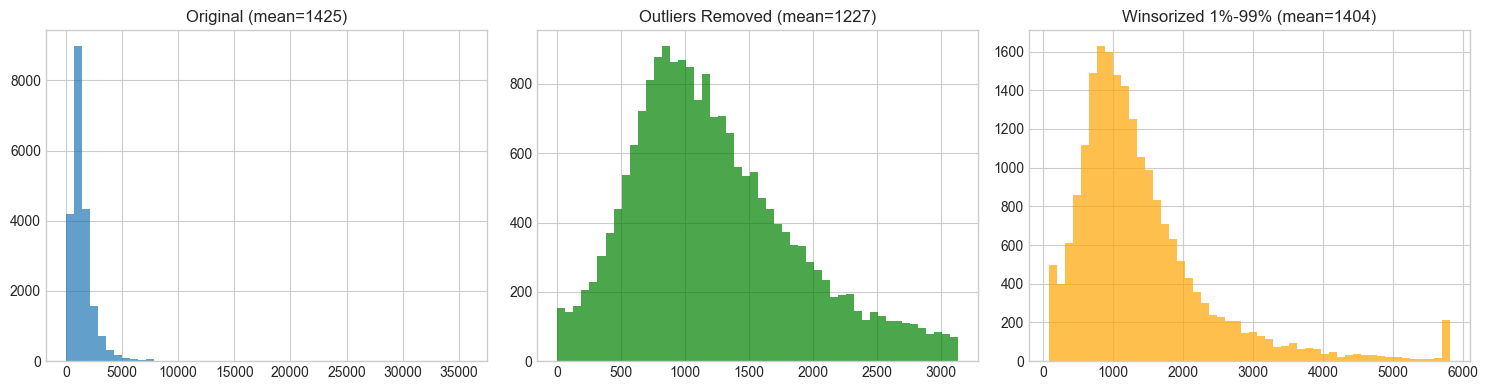

In [23]:
# Outlier detection and handling
feature = 'Population'
data = df_housing[feature]

# IQR method
Q1, Q3 = data.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = (data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)

print(f"Outliers in {feature}: {outliers.sum()} ({outliers.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data, bins=50, alpha=0.7)
axes[0].set_title(f'Original (mean={data.mean():.0f})')

axes[1].hist(data[~outliers], bins=50, alpha=0.7, color='green')
axes[1].set_title(f'Outliers Removed (mean={data[~outliers].mean():.0f})')

data_winsorized = winsorize(data, limits=[0.01, 0.01])
axes[2].hist(data_winsorized, bins=50, alpha=0.7, color='orange')
axes[2].set_title(f'Winsorized 1%-99% (mean={data_winsorized.mean():.0f})')

plt.tight_layout()
plt.show()

---
## Part 4: PCA for Dimensionality Reduction (Digits Dataset)

In [24]:
# Load digits
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Digits: {X_digits.shape[0]} samples, {X_digits.shape[1]} features (8x8 pixels)")

# Standardize
X_scaled = StandardScaler().fit_transform(X_digits)

Digits: 1797 samples, 64 features (8x8 pixels)


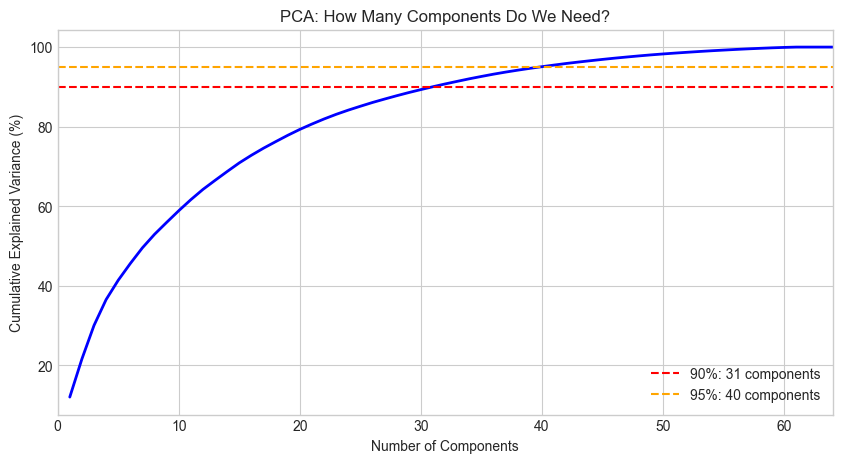


64D → 31D for 90% variance = 52% reduction


In [25]:
# Apply PCA and check explained variance
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cumsum = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(cumsum >= 0.90) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum)+1), cumsum * 100, 'b-', linewidth=2)
plt.axhline(90, color='red', linestyle='--', label=f'90%: {n_90} components')
plt.axhline(95, color='orange', linestyle='--', label=f'95%: {n_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA: How Many Components Do We Need?')
plt.legend()
plt.xlim(0, 64)
plt.show()

print(f"\n64D → {n_90}D for 90% variance = {(1-n_90/64)*100:.0f}% reduction")

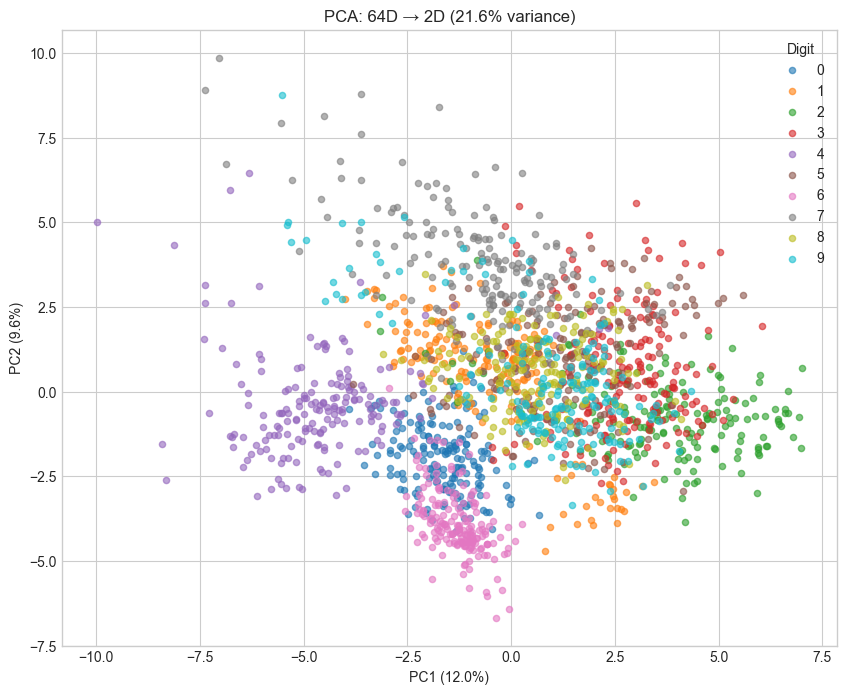

In [26]:
# Visualize in 2D with PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
for digit in range(10):
    mask = y_digits == digit
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=str(digit), alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'PCA: 64D → 2D ({sum(pca_2d.explained_variance_ratio_)*100:.1f}% variance)')
plt.legend(title='Digit')
plt.show()

---
## Part 5: Comparing PCA, LDA, t-SNE, and UMAP

In [27]:
# Use subset for speed
np.random.seed(42)
idx = np.random.choice(len(X_digits), 1000, replace=False)
X_sub, y_sub = X_scaled[idx], y_digits[idx]

print("Computing projections...")

# PCA
pca_result = PCA(n_components=2).fit_transform(X_sub)
print("  PCA done")

# LDA (supervised)
lda_result = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_sub, y_sub)
print("  LDA done")

# t-SNE
tsne_result = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_sub)
print("  t-SNE done")

# UMAP
if UMAP_AVAILABLE:
    umap_result = umap.UMAP(n_components=2, random_state=42).fit_transform(X_sub)
    print("  UMAP done")
else:
    umap_result = None

Computing projections...
  PCA done
  LDA done


  File "C:\Users\1721251\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


  t-SNE done
  UMAP done


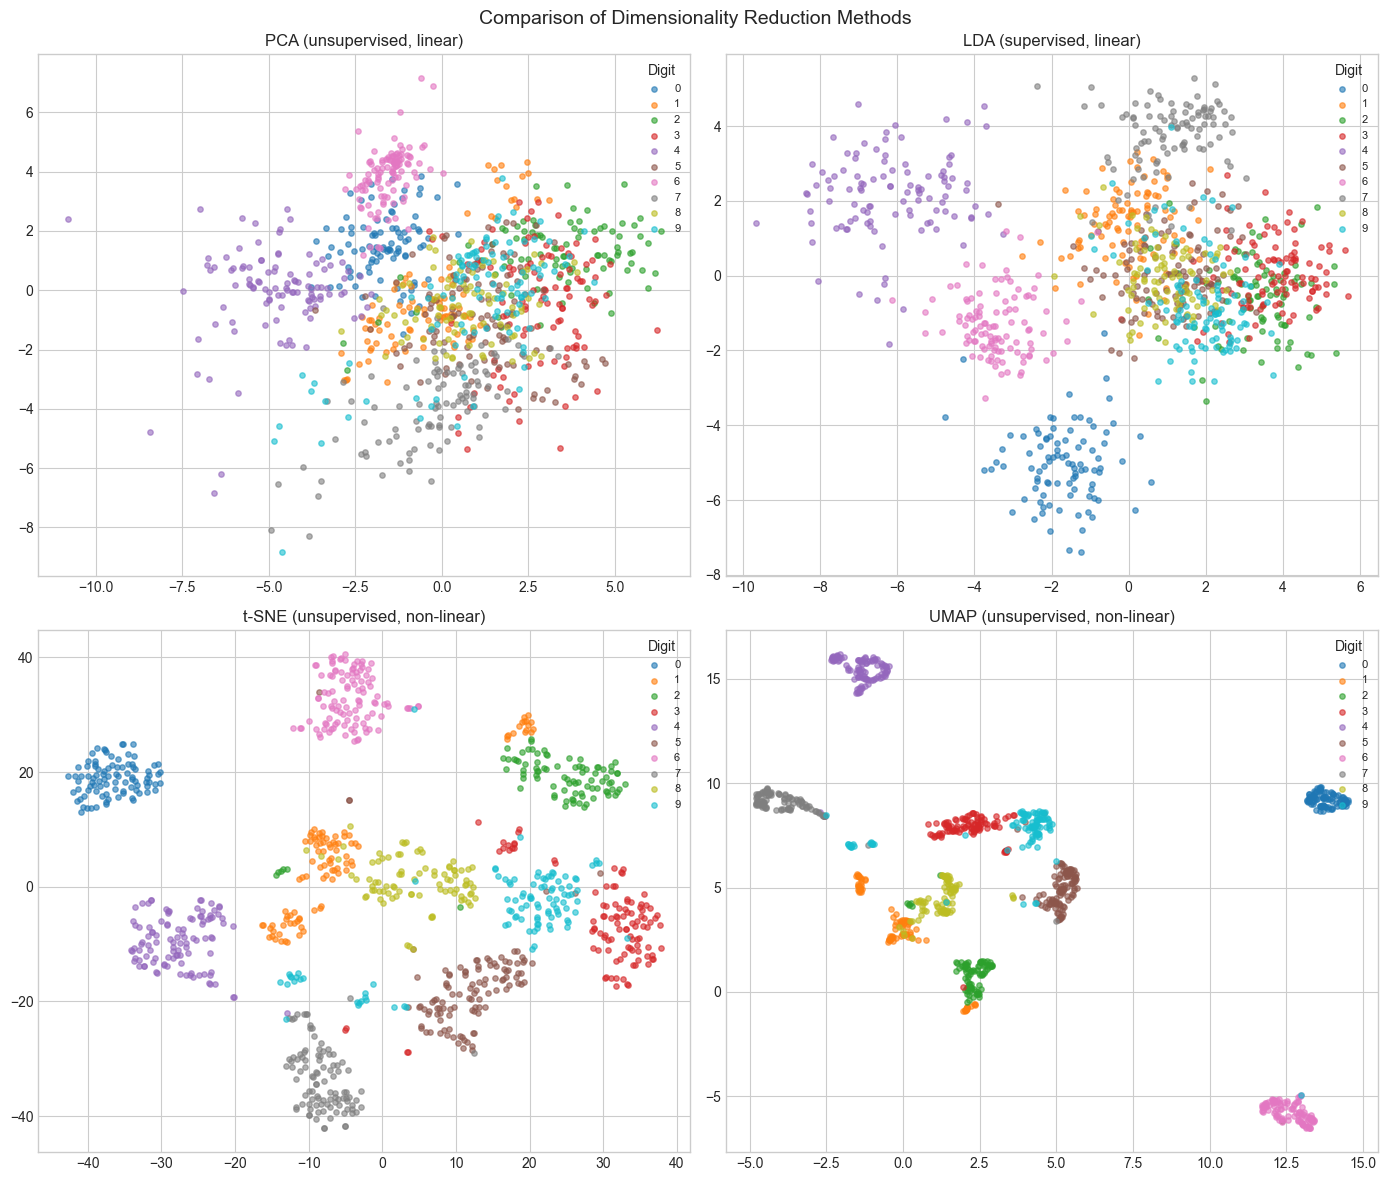


Key Observations:
• PCA: Fast, but clusters overlap significantly
• LDA: Better separation (uses labels!) but still linear
• t-SNE: Clear clusters, but slow and can't transform new data
• UMAP: Similar to t-SNE but faster and can transform new data


In [28]:
# Compare visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

results = [
    (pca_result, 'PCA (unsupervised, linear)'),
    (lda_result, 'LDA (supervised, linear)'),
    (tsne_result, 't-SNE (unsupervised, non-linear)'),
    (umap_result if UMAP_AVAILABLE else pca_result, 'UMAP (unsupervised, non-linear)' if UMAP_AVAILABLE else 'UMAP not available')
]

for ax, (data, title) in zip(axes.flat, results):
    for digit in range(10):
        mask = y_sub == digit
        ax.scatter(data[mask, 0], data[mask, 1], label=str(digit), alpha=0.6, s=15)
    ax.set_title(title, fontsize=12)
    ax.legend(title='Digit', loc='upper right', fontsize=8)

plt.suptitle('Comparison of Dimensionality Reduction Methods', fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("• PCA: Fast, but clusters overlap significantly")
print("• LDA: Better separation (uses labels!) but still linear")
print("• t-SNE: Clear clusters, but slow and can't transform new data")
print("• UMAP: Similar to t-SNE but faster and can transform new data")

---
## Summary

| Technique | When to Use |
|-----------|-------------|
| **Missing Values** | Median for numerical, mode for categorical |
| **Min-Max Scaling** | When you need bounded [0,1] range |
| **Standardization** | Before PCA, for most algorithms |
| **Log Transform** | For highly skewed data |
| **PCA** | General dimensionality reduction, preprocessing |
| **LDA** | When you have labels and want class separation |
| **t-SNE/UMAP** | Visualization of high-dimensional data |